In [103]:
#Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold, cross_validate,cross_val_score
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import time
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import collections

# Other Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold
import warnings
warnings.filterwarnings("ignore")

Now we are going to explore the dataset and doing the EDA.

In [104]:
df = pd.read_csv('creditcard.csv')

# Basic inspection
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()
#df.isnull().sum().max()

Shape: (284807, 31)

Column names:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [105]:
print(df['Class'].value_counts()) 
#we are going to check how many fraud transactions found
# 0 represented the legitimate transactions and 1 illegal transactions

df[['Amount', 'Time']].describe()
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

Class
0    284315
1       492
Name: count, dtype: int64
No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


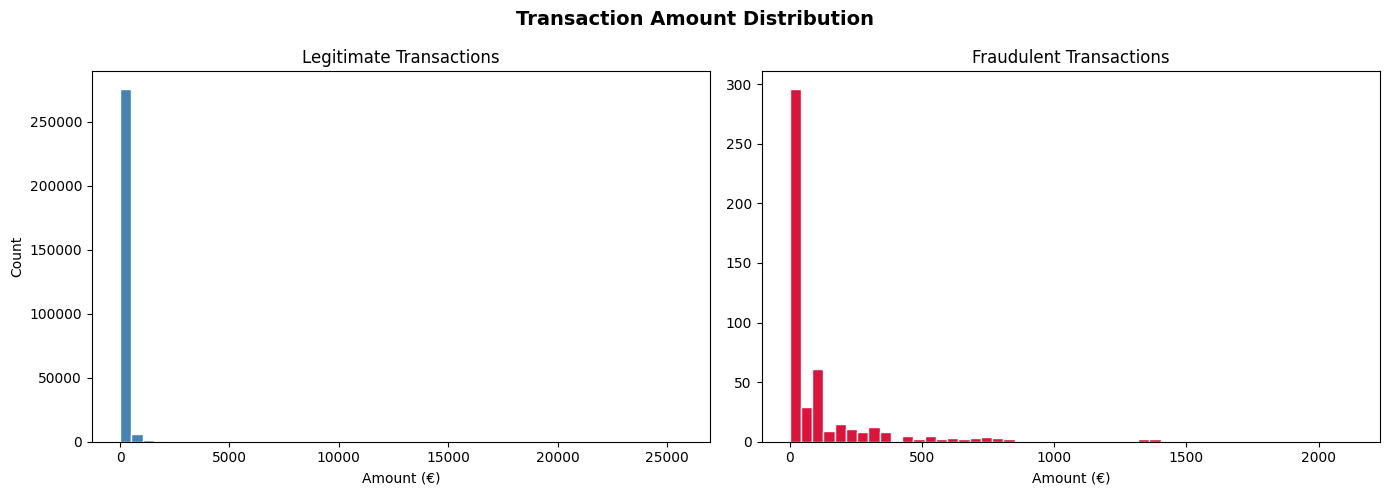

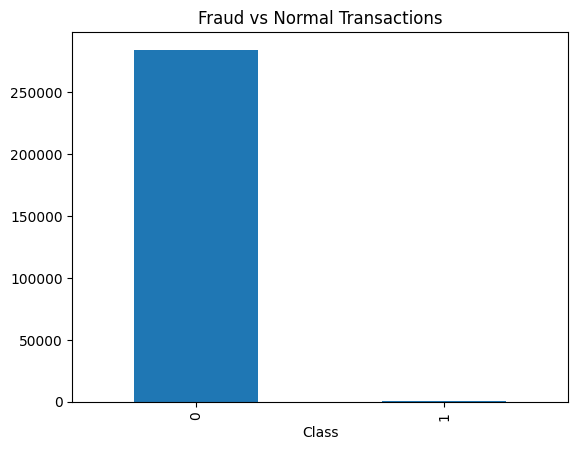

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Legitimate
axes[0].hist(df[df['Class']==0]['Amount'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Legitimate Transactions')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Count')

# Fraud
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, color='crimson', edgecolor='white')
axes[1].set_title('Fraudulent Transactions')
axes[1].set_xlabel('Amount (€)')

plt.suptitle('Transaction Amount Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparison Distribtion fraud vs Legal transactions
df['Class'].value_counts().plot(kind='bar')
plt.title("Fraud vs Normal Transactions")
plt.show()

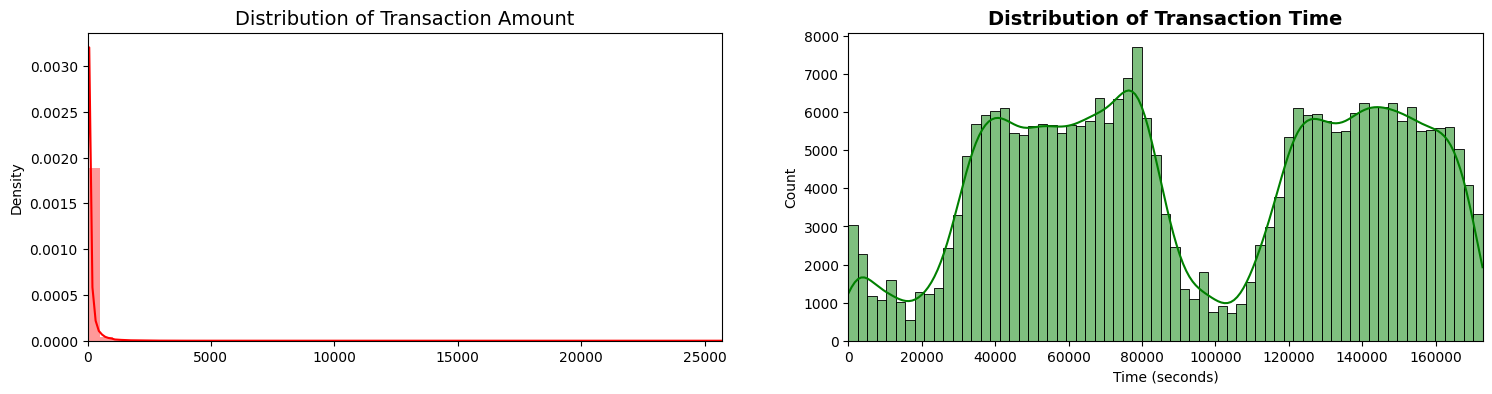

In [107]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = df['Amount'].values
time_val = df['Time'].values

# Amount distribution
#sns.histplot(amount_val, ax=ax[0], color='crimson', kde=True)
#ax[0].set_title('Distribution of Transaction Amount', fontsize=14, fontweight='bold')
#ax[0].set_xlim([min(amount_val), max(amount_val)])
#ax[0].set_xlabel('Amount (€)')

sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

#sns.distplot(time_val, ax=ax[1], color='g')
#ax[1].set_title('Distribution of Transaction Time', fontsize=14)
#ax[1].set_xlim([min(time_val), max(time_val)])
sns.histplot(time_val, ax=ax[1], color='green', kde=True)
ax[1].set_title('Distribution of Transaction Time', fontsize=14, fontweight='bold')
ax[1].set_xlim([min(time_val), max(time_val)])
ax[1].set_xlabel('Time (seconds)')

plt.show()




Now let's focus on the trend of fraud transaction over time and explore the correlation

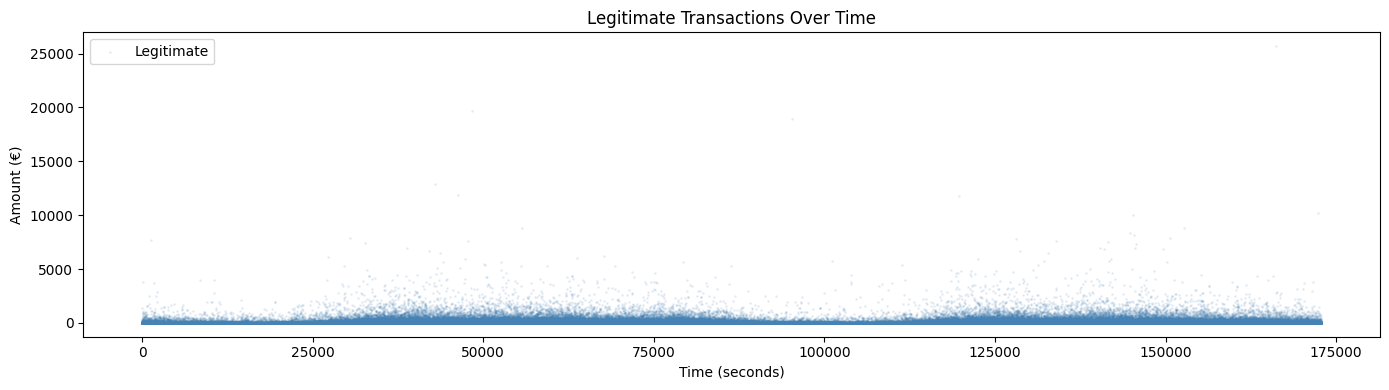

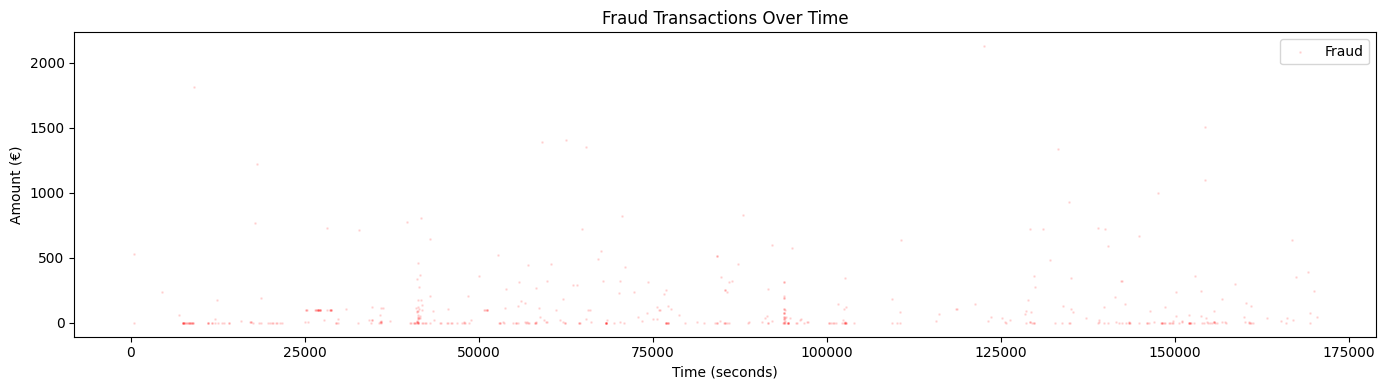

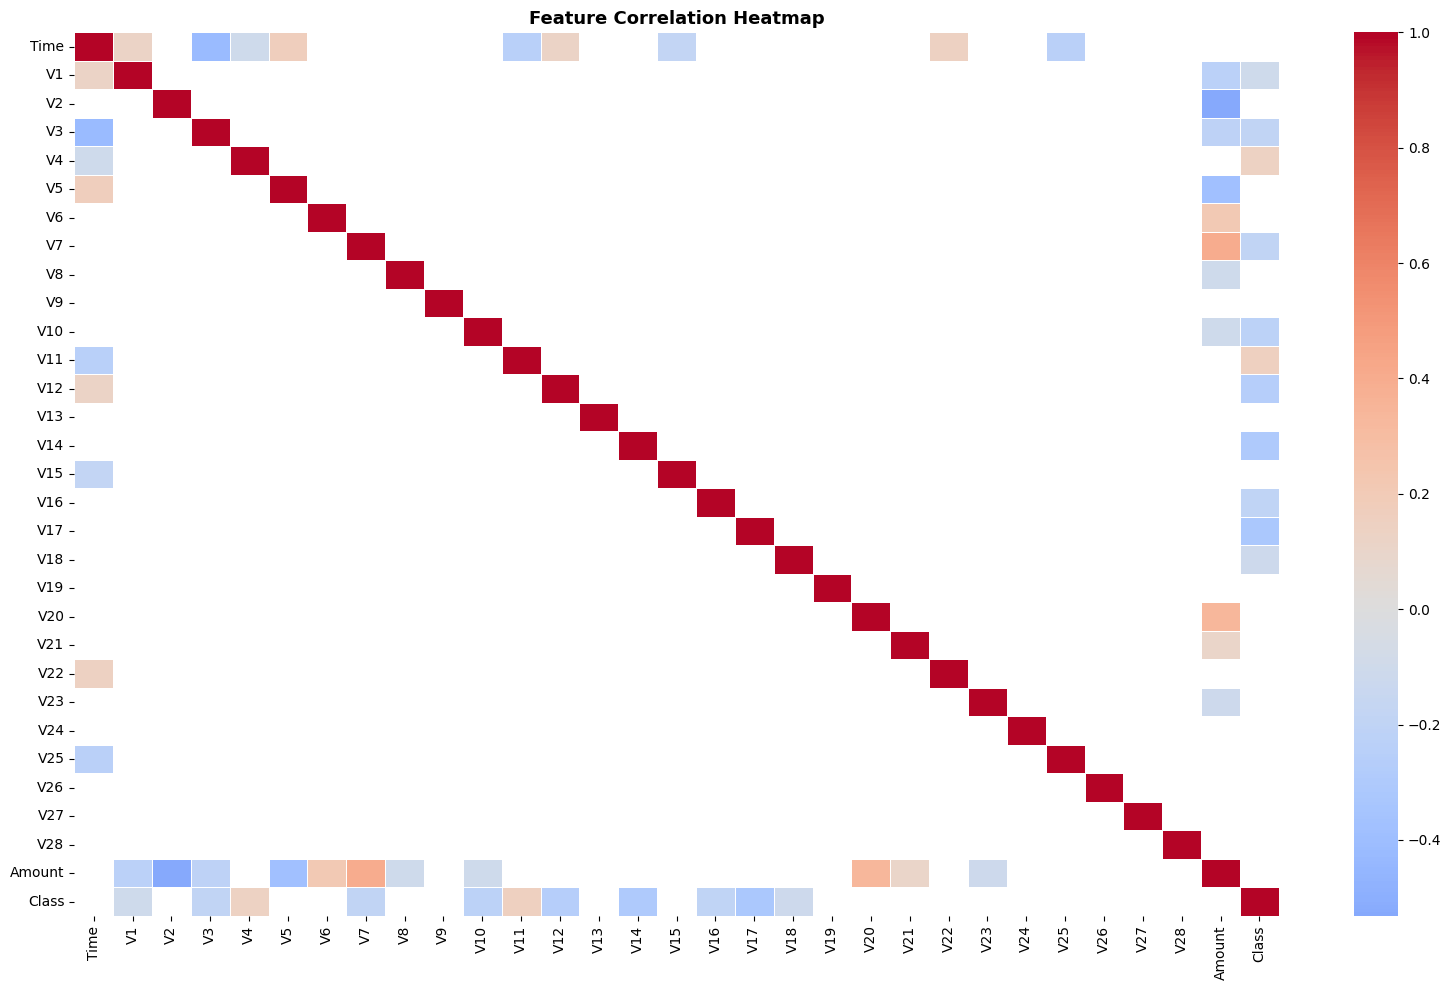

In [108]:
plt.figure(figsize=(14, 4))
plt.scatter(df[df['Class']==0]['Time'], df[df['Class']==0]['Amount'],
            alpha=0.1, s=1, color='steelblue', label='Legitimate')
plt.title('Legitimate Transactions Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Amount (€)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.scatter(df[df['Class']==1]['Time'], df[df['Class']==1]['Amount'],
            alpha=0.1, s=1, color='red', label='Fraud')
plt.title('Fraud Transactions Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Amount (€)')
plt.legend()
plt.tight_layout()
plt.show()


#Correlation Heatmap
plt.figure(figsize=(16, 10))
corr = df.corr()
mask = corr.abs() < 0.1  # only show meaningful correlations

sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.5, annot=False)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Observations:

The majority cluster below 1000 euros, only few outliers go up to 20000, theses are probably the high-value business transations, there are not unusual spikes and the points are consistent across all time periods.

The plot 2 shows that the amount of fraud transations are much smaller, around 100 or 200 euros with a maximum around 2000, fraud appears scattered across all time periods.

V1, V3, V4, V9, V10, V11, V14, V16, V17 show notable correlation with Class (fraud label) in the plot3.
Most V features are uncorrelated with each other (PCA already removed that) — good, no multicollinearity
Amount has weak but visible correlation with some features

In [109]:
#we move to the silver layer and do the robustscaler 
#formula scaled_value = (value - median) / IQR
#IQR = Q75 - Q25  ← middle 50% of data, unaffected by extremes

scaler = RobustScaler()

# Scale Amount and Time
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time']   = scaler.fit_transform(df[['Time']])

# Drop original columns
df_silver = df.drop(columns=['Amount', 'Time'])

# Separate features and label
X = df_silver.drop(columns=['Class'])
y = df_silver['Class']

print("Silver layer shape:", X.shape)
print("Sample scaled values:")
df_silver[['scaled_amount', 'scaled_time']].describe()

Silver layer shape: (284807, 30)
Sample scaled values:


,scaled_amount,scaled_time
count,284807.000000,284807.000000
mean,0.927124,0.118914
std,3.495006,0.557903
min,-0.307413,-0.994983
25%,-0.229162,-0.358210
50%,0.000000,0.000000
75%,0.770838,0.641790
max,358.683155,1.035022


Due to the extremely imbalanced dataset, (heavily imbalanced), fraud transactions represent less than 1%, I will use the stratifiedKfold to ensure every training fold maintained the same fraud ratior, preventing the model from developping a bias towards legitimate transactions.  
This ensures:
Same fraud ratio in each split
No bias during training
In imbalanced data, we can consider that splitting strategy = model quality.

In [110]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    print(f"Fold {fold+1}:")
    print(f"  Train fraud rate: {y_train.mean():.4f}")
    print(f"  Val   fraud rate: {y_val.mean():.4f}")


original_Xtrain = X_train.values
original_Xtest = X_val.values
original_ytrain = y_train.values
original_ytest = y_val.values

Fold 1:
  Train fraud rate: 0.0017
  Val   fraud rate: 0.0017
Fold 2:
  Train fraud rate: 0.0017
  Val   fraud rate: 0.0017
Fold 3:
  Train fraud rate: 0.0017
  Val   fraud rate: 0.0017
Fold 4:
  Train fraud rate: 0.0017
  Val   fraud rate: 0.0017
Fold 5:
  Train fraud rate: 0.0017
  Val   fraud rate: 0.0017


StratifiedKFold only ensures each validation fold has the same rare class ratio( honest performance estimate).

However!!!!!

It does not change the training set distribution. The model still trains on imbalanced data inside each fold’s training split.
So we need to use Undersampling changes the training set itself.

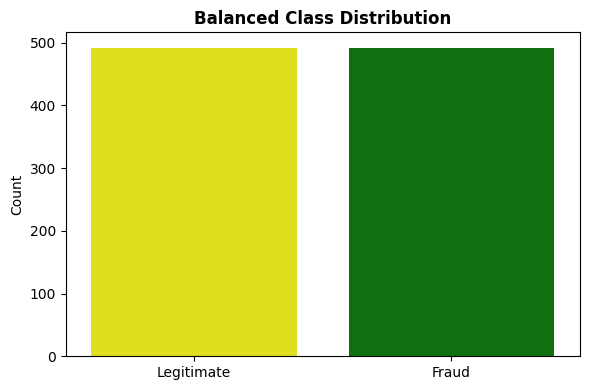

Class distribution:
 Class
1    492
0    492
Name: count, dtype: int64


In [111]:
fraud_df     = df[df['Class'] == 1]          # all 492 fraud cases
non_fraud_df = df[df['Class'] == 0][:492]    # only 492 legitimate cases

new_df = pd.concat([fraud_df, non_fraud_df]) # 984 total, perfectly balanced

# Print out the visualisation
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=new_df, palette=['yellow', 'green'])
plt.title('Balanced Class Distribution', fontweight='bold')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.xlabel('')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("Class distribution:\n", new_df['Class'].value_counts())

After this setup, we obtain a balanced dataset.
Now let's explore the correlation again.

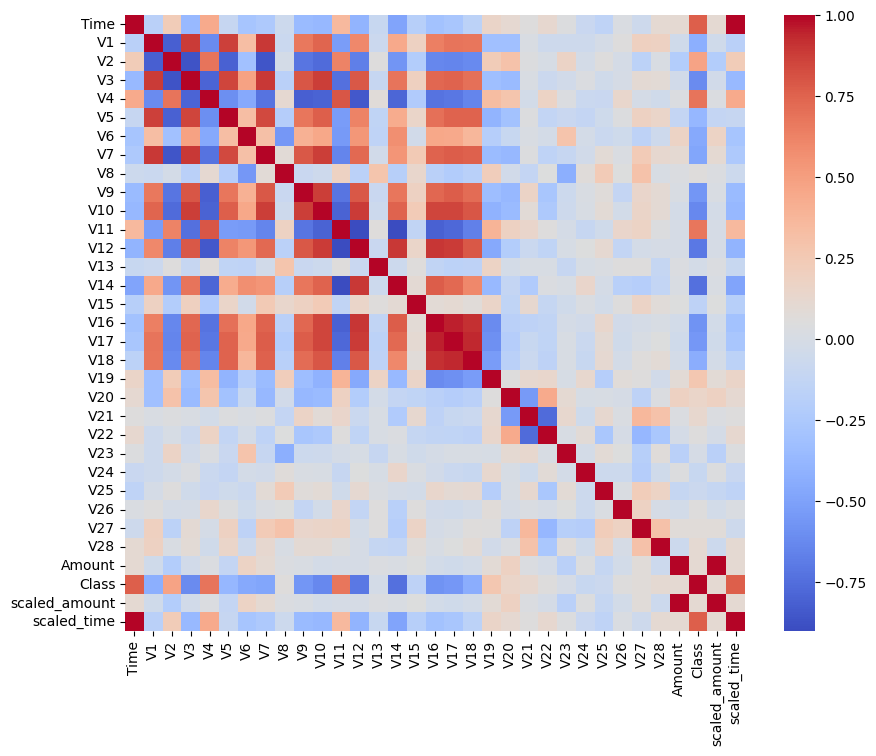

In [112]:
plt.figure(figsize=(10,8))
sns.heatmap(new_df.corr(), cmap='coolwarm')
plt.show()

We clearly observed that V17, V14, V12 negatively and V11,V2, V4 positively. 

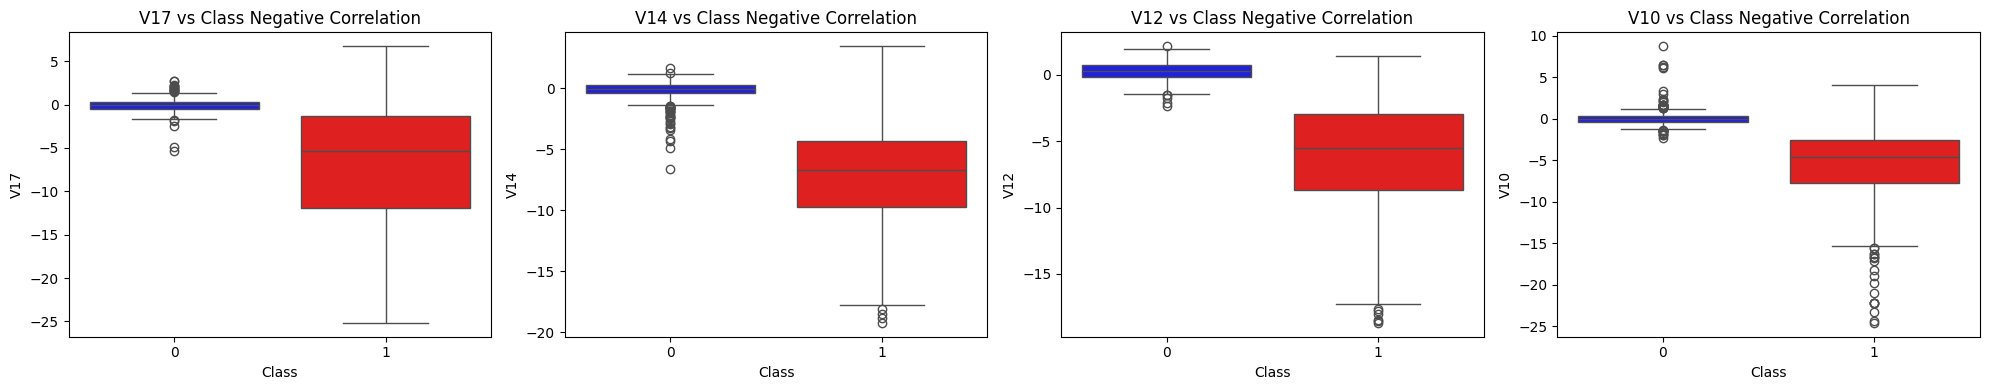

In [113]:
colors = {0: 'blue', 1: 'red'}

f, axes = plt.subplots(ncols=4, figsize=(20, 4))

sns.boxplot(x="Class", y="V17", data=new_df, hue="Class", palette=colors, legend=False, ax=axes[0])
axes[0].set_title('V17 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V14", data=new_df, hue="Class", palette=colors, legend=False, ax=axes[1])
axes[1].set_title('V14 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V12", data=new_df, hue="Class", palette=colors, legend=False, ax=axes[2])
axes[2].set_title('V12 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V10", data=new_df, hue="Class", palette=colors, legend=False, ax=axes[3])
axes[3].set_title('V10 vs Class Negative Correlation')

plt.tight_layout()
plt.show()

The blue box is very flat = legitimate transactions are consistent and predictable. In contrast, the red box is very large and fraud transactions vary wildly in negative zone.
The boxplots confirmed that fraud transactions have distinctly lower values for V17, V14, V12 and V10 — these features alone could flag suspicious transactions in the system.

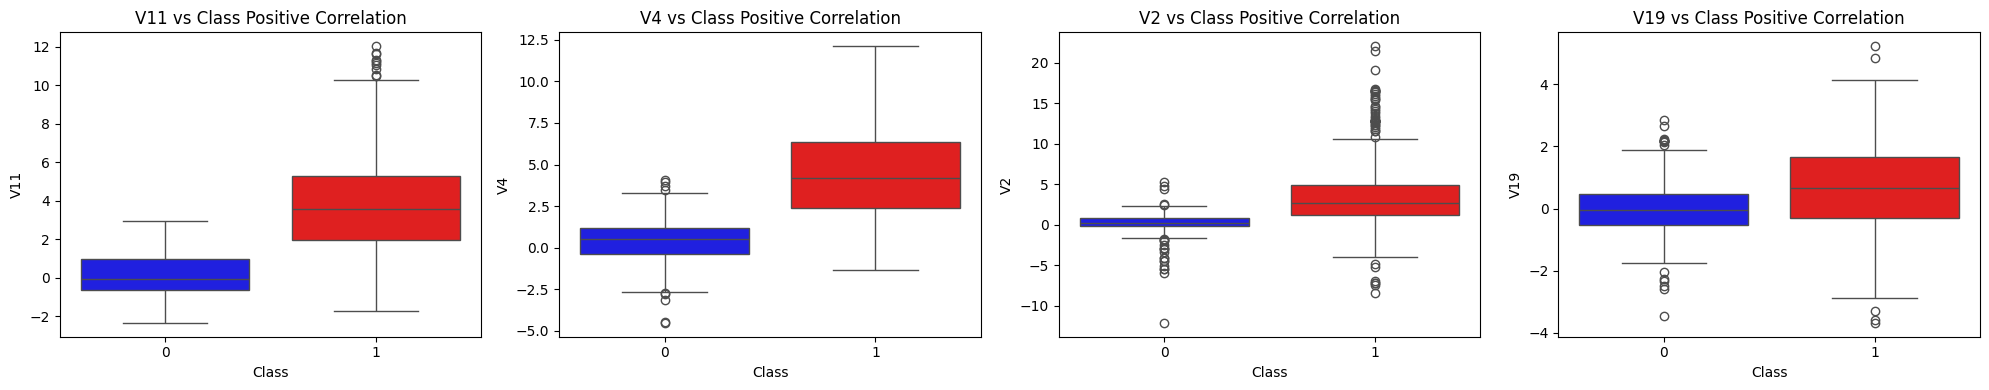

In [114]:
f, axes = plt.subplots(ncols=4, figsize=(20, 4))

sns.boxplot(x="Class", y="V11", data=new_df, hue="Class", palette=colors, legend=False, ax=axes[0])
axes[0].set_title('V11 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V4", data=new_df, hue="Class", palette=colors, legend=False, ax=axes[1])
axes[1].set_title('V4 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V2", data=new_df, hue="Class", palette=colors, legend=False, ax=axes[2])
axes[2].set_title('V2 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V19", data=new_df, hue="Class", palette=colors, legend=False, ax=axes[3])
axes[3].set_title('V19 vs Class Positive Correlation')

plt.tight_layout()
plt.show()

Let's plot the distribution of fraud transactions for V14, V12, V10 and fits a normal distribution curve on top.

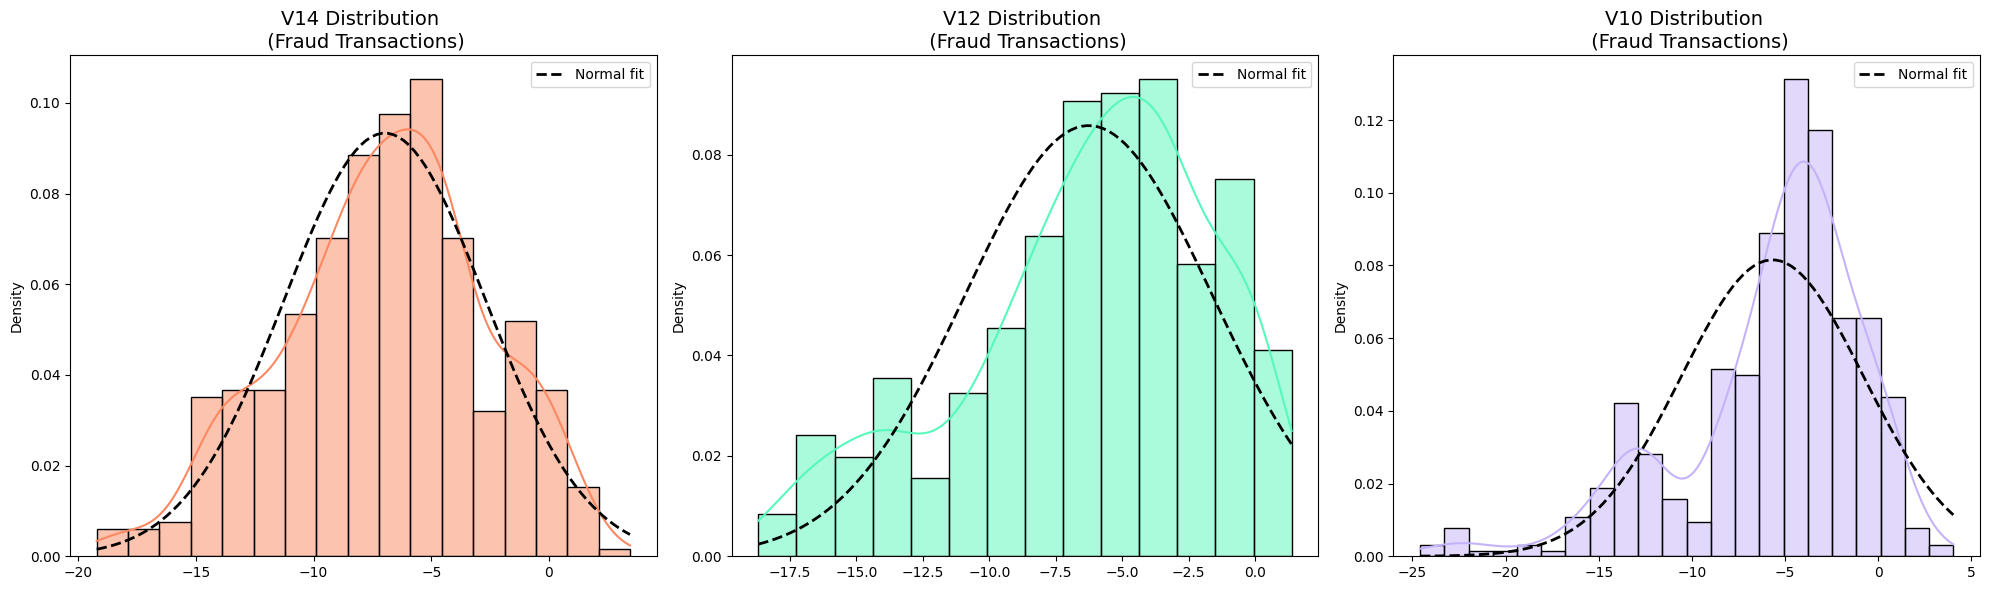

In [115]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# V14 Fraud Distribution
v14_fraud_dist = new_df['V14'].loc[new_df['Class'] == 1].values
sns.histplot(v14_fraud_dist, ax=ax1, kde=True, color='#FB8861', stat='density')
mu, std = norm.fit(v14_fraud_dist)
x = np.linspace(v14_fraud_dist.min(), v14_fraud_dist.max(), 100)
ax1.plot(x, norm.pdf(x, mu, std), 'k--', linewidth=2, label='Normal fit')
ax1.set_title('V14 Distribution \n (Fraud Transactions)', fontsize=14)
ax1.legend()

# V12 Fraud Distribution
v12_fraud_dist = new_df['V12'].loc[new_df['Class'] == 1].values
sns.histplot(v12_fraud_dist, ax=ax2, kde=True, color='#56F9BB', stat='density')
mu, std = norm.fit(v12_fraud_dist)
x = np.linspace(v12_fraud_dist.min(), v12_fraud_dist.max(), 100)
ax2.plot(x, norm.pdf(x, mu, std), 'k--', linewidth=2, label='Normal fit')
ax2.set_title('V12 Distribution \n (Fraud Transactions)', fontsize=14)
ax2.legend()

# V10 Fraud Distribution
v10_fraud_dist = new_df['V10'].loc[new_df['Class'] == 1].values
sns.histplot(v10_fraud_dist, ax=ax3, kde=True, color='#C5B3F9', stat='density')
mu, std = norm.fit(v10_fraud_dist)
x = np.linspace(v10_fraud_dist.min(), v10_fraud_dist.max(), 100)
ax3.plot(x, norm.pdf(x, mu, std), 'k--', linewidth=2, label='Normal fit')
ax3.set_title('V10 Distribution \n (Fraud Transactions)', fontsize=14)
ax3.legend()

plt.tight_layout()
plt.show()

By analyzing the fraud-only transactions, we observed that features V14 and V12 exhibit a left-skewed, roughly bell-shaped distribution with fraud values clustering in the negative range, while V10 shows a wider spread with heavier tails, indicating greater variability in fraudulent amounts.For example, V14 has densities of 0.038 at -15, 0.072 at -10, 0.105 at -5, tapering to 0.050 at 0 — which closely resembles the left half of a normal distribution centered in the negative region.

This quantitative fit confirms that fraud transactions for these features are approximately Gaussian (bell-shaped but left-skewed relative to zero),which means most fraud values cluster around a negative mean.

Extreme positive values in these features are rare for fraud → thus more likely to be anomalies (non-fraud).

We applied IQR-based outlier removal separately on three features (V14, V12, V10) — but only using the fraud-class transactions (Class = 1) to define the outlier bounds.

For each feature:

Extract values only from fraud cases

Calculate Q25 (25th percentile) and Q75 (75th percentile)

Compute IQR = Q75 - Q25

Define lower bound = Q25 - 1.5×IQR, upper bound = Q75 + 1.5×IQR

Remove any row (both fraud and non-fraud) where that feature falls outside these bounds

In [116]:
 # -----> V14 Removing Outliers (Highest Negative Correlated with Labels)
v14_fraud = new_df['V14'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
print('Quartile 25: {} | Quartile 75: {}'.format(q25, q75))
v14_iqr = q75 - q25
print('iqr: {}'.format(v14_iqr))

v14_cut_off = v14_iqr * 1.5
v14_lower, v14_upper = q25 - v14_cut_off, q75 + v14_cut_off
print('Cut Off: {}'.format(v14_cut_off))
print('V14 Lower: {}'.format(v14_lower))
print('V14 Upper: {}'.format(v14_upper))

outliers = [x for x in v14_fraud if x < v14_lower or x > v14_upper]
print('Feature V14 Outliers for Fraud Cases: {}'.format(len(outliers)))
print('V10 outliers:{}'.format(outliers))

new_df = new_df.drop(new_df[(new_df['V14'] > v14_upper) | (new_df['V14'] < v14_lower)].index)
print('----' * 44)

# -----> V12 removing outliers from fraud transactions
v12_fraud = new_df['V12'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v12_fraud, 25), np.percentile(v12_fraud, 75)
v12_iqr = q75 - q25

v12_cut_off = v12_iqr * 1.5
v12_lower, v12_upper = q25 - v12_cut_off, q75 + v12_cut_off
print('V12 Lower: {}'.format(v12_lower))
print('V12 Upper: {}'.format(v12_upper))
outliers = [x for x in v12_fraud if x < v12_lower or x > v12_upper]
print('V12 outliers: {}'.format(outliers))
print('Feature V12 Outliers for Fraud Cases: {}'.format(len(outliers)))
new_df = new_df.drop(new_df[(new_df['V12'] > v12_upper) | (new_df['V12'] < v12_lower)].index)
print('Number of Instances after outliers removal: {}'.format(len(new_df)))
print('----' * 44)


# Removing outliers V10 Feature
v10_fraud = new_df['V10'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
v10_iqr = q75 - q25

v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off
print('V10 Lower: {}'.format(v10_lower))
print('V10 Upper: {}'.format(v10_upper))
outliers = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print('V10 outliers: {}'.format(outliers))
print('Feature V10 Outliers for Fraud Cases: {}'.format(len(outliers)))
new_df = new_df.drop(new_df[(new_df['V10'] > v10_upper) | (new_df['V10'] < v10_lower)].index)
print('Number of Instances after outliers removal: {}'.format(len(new_df)))

Quartile 25: -9.692722964972386 | Quartile 75: -4.282820849486865
iqr: 5.409902115485521
Cut Off: 8.114853173228282
V14 Lower: -17.807576138200666
V14 Upper: 3.8320323237414167
Feature V14 Outliers for Fraud Cases: 4
V10 outliers:[-19.2143254902614, -18.8220867423816, -18.4937733551053, -18.0499976898594]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
V12 Lower: -17.3430371579634
V12 Upper: 5.776973384895937
V12 outliers: [-18.0475965708216, -18.6837146333443, -18.5536970096458, -18.4311310279993]
Feature V12 Outliers for Fraud Cases: 4
Number of Instances after outliers removal: 976
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
V10 Lower: -14.89885463232024
V10 Upper: 4.92033495834214
V10 outliers: [-15.1241628144947, -16.649628

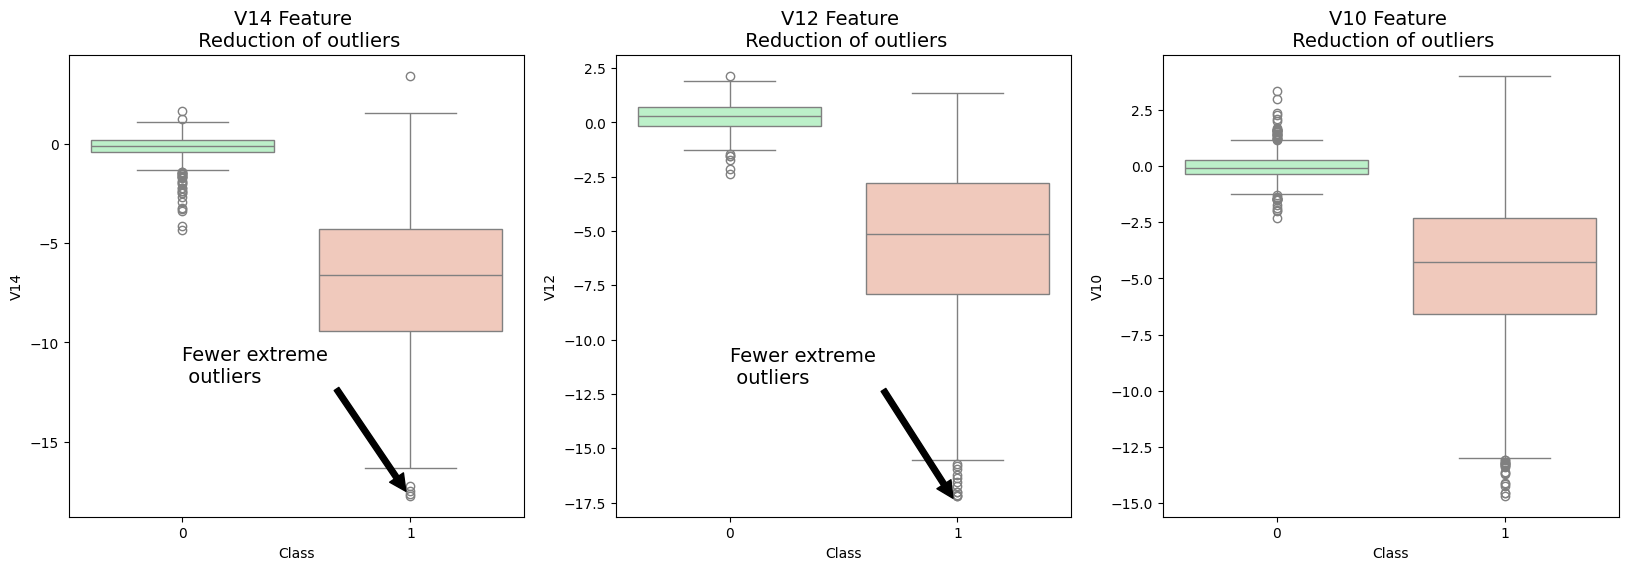

In [117]:
f,(ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,6))

colors = ['#B3F9C5', '#f9c5b3']
# Boxplots with outliers removed
# Feature V14
sns.boxplot(x="Class", y="V14", data=new_df,ax=ax1, palette=colors)
ax1.set_title("V14 Feature \n Reduction of outliers", fontsize=14)
ax1.annotate('Fewer extreme \n outliers', xy=(0.98, -17.5), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)

# Feature 12
sns.boxplot(x="Class", y="V12", data=new_df, ax=ax2, palette=colors)
ax2.set_title("V12 Feature \n Reduction of outliers", fontsize=14)
ax2.annotate('Fewer extreme \n outliers', xy=(0.98, -17.3), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)

# Feature V10
sns.boxplot(x="Class", y="V10", data=new_df, ax=ax3, palette=colors)
ax3.set_title("V10 Feature \n Reduction of outliers", fontsize=14)
ax3.annotate('Fewer extreme \n outliers', xy=(0.95, -16.5), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)


plt.show()

Cross-Validation

In [ ]:
# Prepare your balanced dataset (already cleaned)
# X = new_df.drop(columns=['Class'])
# y = new_df['Class']

# # Initialize model
# model = xgb.XGBClassifier(
#     n_estimators=100,
#     max_depth=6,
#     learning_rate=0.1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     eval_metric='logloss',
#     use_label_encoder=False
# )

# # Stratified K-Fold (5 folds)
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation with multiple metrics
# scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
# cv_results = cross_validate(model, X, y, cv=skf, scoring=scoring, return_train_score=False)

# # Display results
# print("\n" + "="*60)
# print("5-FOLD CROSS-VALIDATION RESULTS (Balanced Data)")
# print("="*60)
# for metric in scoring:
#     scores = cv_results[f'test_{metric}']
#     print(f"{metric.upper():10s}: {scores.mean():.4f} (+/- {scores.std():.4f})")


5-FOLD CROSS-VALIDATION RESULTS (Balanced Data)
ACCURACY  : 0.9989 (+/- 0.0021)
PRECISION : 1.0000 (+/- 0.0000)
RECALL    : 0.9978 (+/- 0.0044)
F1        : 0.9989 (+/- 0.0022)
ROC_AUC   : 1.0000 (+/- 0.0000)


In [ ]:
# Your balanced data (used for training and CV)
# X_balanced = new_df.drop(columns=['Class'])
# y_balanced = new_df['Class']

# # Your ORIGINAL imbalanced data (from earlier in your notebook)
# # This is your df_silver before any balancing
# X_original = df.drop(columns=['Class'])  # 284,807 rows
# y_original = df['Class']

# print(f"Balanced dataset size: {len(X_balanced)}")
# print(f"Original dataset size: {len(X_original)}")
# print(f"Original fraud %: {y_original.mean()*100:.4f}%")

Balanced dataset size: 944
Original dataset size: 284807
Original fraud %: 0.1727%


In [120]:
# Train on ALL balanced data 
final_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Train
final_model.fit(X_balanced, y_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)